In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("data/temp", exist_ok=True)
os.makedirs("data/clean", exist_ok=True)

# Video Game Success Analysis

## Introduction
This project analyzes the factors that influence video game sales using multiple datasets. The goal is to understand how features such as genre, platform, release year, and review scores relate to commercial success.

The analysis includes data cleaning, exploratory data analysis (EDA), statistical testing, and predictive modeling TBD*.

## Problem Statement

What factors determine the commercial success of a video game?

In this project, success is measured using **global sales**. The analysis investigates how different variables such as genre, platform, and review scores affect sales performance.

## Data Sources

This project uses two independent datasets:

- vgsales.csv: Video game sales data (VGChartz)
- Video_Games.csv: Video game sales and ratings (includes critic and user scores)

The datasets will be merged to enrich the analysis and provide a more complete view of video game success factors.

## Initial Data Inspection

In this section, we explore the structure, data types, and basic statistics of both datasets to identify potential issues such as missing values, inconsistent formats, and anomalies.

In [2]:
vgsales_raw = pd.read_csv("data/raw/vgsales.csv")
video_games_raw = pd.read_csv("data/raw/Video_Games.csv")

### vgsales raw exploration

In [3]:
vgsales_raw.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
vgsales_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [5]:
vgsales_raw.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [6]:
vgsales_raw.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [7]:
vgsales_raw.shape

(16598, 11)

### Video_Games raw exploration

In [8]:
video_games_raw.head()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
video_games_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 16928 entries, 0 to 16927
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            16928 non-null  int64  
 1   Name             16926 non-null  str    
 2   Platform         16928 non-null  str    
 3   Year_of_Release  16655 non-null  float64
 4   Genre            16926 non-null  str    
 5   Publisher        16873 non-null  str    
 6   NA_Sales         16928 non-null  float64
 7   EU_Sales         16928 non-null  float64
 8   JP_Sales         16928 non-null  float64
 9   Other_Sales      16928 non-null  float64
 10  Global_Sales     16928 non-null  float64
 11  Critic_Score     8260 non-null   float64
 12  Critic_Count     8260 non-null   float64
 13  User_Score       10159 non-null  str    
 14  User_Count       7718 non-null   float64
 15  Developer        10240 non-null  str    
 16  Rating           10092 non-null  str    
dtypes: float64(9), int64(1)

We take note that User_Score is a string, could contain some broken data.

In [10]:
video_games_raw.describe()

,index,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16928.000000,16655.00000,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,8260.000000,8260.000000,7718.000000
mean,8463.500000,2006.48532,0.266390,0.146850,0.078170,0.047861,0.539520,69.037893,26.428692,163.269629
std,4886.837014,5.88289,0.814326,0.504585,0.308756,0.186675,1.550545,13.943198,18.989929,562.786746
min,0.000000,1980.00000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,4231.750000,2003.00000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,8463.500000,2007.00000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,25.000000
75%,12695.250000,2010.00000,0.240000,0.110000,0.040000,0.040000,0.490000,79.000000,36.000000,82.000000
max,16927.000000,2020.00000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [11]:
video_games_raw.columns

Index(['index', 'Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher',
       'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales',
       'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer',
       'Rating'],
      dtype='str')

In [12]:
video_games_raw.shape

(16928, 17)

### Observations

- vgsales_raw contains basic sales and metadata but lacks review scores
- video_games_raw includes additional features such as critic and user scores
- There are missing values in several columns, particularly in review-related fields
- The column names differ between datasets (e.g., "Year" vs "Year_of_Release")
- Some columns may have incorrect data types (e.g., User_Score as string)

These issues will be addressed in the data cleaning phase.

## Data Cleaning

In this section, we prepare both datasets for analysis by handling missing values, fixing data types, and ensuring consistency between datasets.

### Normalizing columns

In [13]:
# normalizing the year column in vgsales
vgsales = vgsales_raw
vgsales = vgsales.rename(columns={"Year": "Year_of_Release"})

In [14]:
# lowercase columns for both datasets
video_games = video_games_raw
video_games.columns = video_games.columns.str.lower()
vgsales.columns = vgsales.columns.str.lower()

In [15]:
vgsales.columns

Index(['rank', 'name', 'platform', 'year_of_release', 'genre', 'publisher',
       'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales'],
      dtype='str')

In [16]:
video_games.columns

Index(['index', 'name', 'platform', 'year_of_release', 'genre', 'publisher',
       'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales',
       'critic_score', 'critic_count', 'user_score', 'user_count', 'developer',
       'rating'],
      dtype='str')

### Inspecting for missing values or broken data

In [17]:
vgsales.isnull().sum()

rank                 0
name                 0
platform             0
year_of_release    271
genre                0
publisher           58
na_sales             0
eu_sales             0
jp_sales             0
other_sales          0
global_sales         0
dtype: int64

In [18]:
video_games.isnull().sum()

index                 0
name                  2
platform              0
year_of_release     273
genre                 2
publisher            55
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
global_sales          0
critic_score       8668
critic_count       8668
user_score         6769
user_count         9210
developer          6688
rating             6836
dtype: int64

In [19]:
# lets check the user score now
video_games.user_score.unique()

<StringArray>
[  '8',   nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
   '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9', '6.4',
 '7.8', '7.5', '2.6', '7.2', '9.2',   '7', '7.3', '4.3', '7.6', '5.7',   '5',
 '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7', '5.4',   '4',
 '4.9', '4.5', '9.3', '6.2', '4.2',   '6', '3.7', '4.1', '5.8', '5.6', '5.5',
 '4.4', '4.6', '5.9', '3.9', '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5',
 '2.5', '1.9',   '3', '2.7', '2.2',   '2', '9.5', '2.1', '3.6', '2.8', '1.8',
 '3.8',   '0', '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
 '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9',   '1', '9.7']
Length: 97, dtype: str

We see that there is a `tbd` value among numbers and nan, which was breaking this column.
I will convert those to nan's so we can properly convert this column's type.

In [20]:
video_games.user_score = video_games.user_score.replace("tbd", np.nan)
video_games.user_score = video_games.user_score.astype(float)

In [21]:
# inspecting years of release
video_games.year_of_release.unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983., 2020., 2017.])

In [22]:
vgsales.year_of_release.unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2003., 1986., 2000.,   nan, 1995., 2016., 1991., 1981., 1987.,
       1980., 1983., 2020., 2017.])

In [23]:
video_games_no_years = video_games[video_games.year_of_release.isna()]
video_games_no_years.head()

,index,name,platform,year_of_release,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,critic_score,critic_count,user_score,user_count,developer,rating
183,183,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23,94.0,29.0,8.5,140.0,EA Tiburon,E
377,377,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49,84.0,20.0,6.4,76.0,EA Canada,E
456,456,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.80,0.97,0.00,0.29,3.06,74.0,17.0,7.9,22.0,Traveller's Tales,E10+
475,475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00,NaN,NaN,NaN,NaN,NaN,NaN
609,609,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
vgsales_no_years = vgsales[vgsales.year_of_release.isna()]
vgsales_no_years.head()

,rank,name,platform,year_of_release,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53


In [25]:
print(vgsales_no_years.shape)
print(video_games_no_years.shape)

(271, 11)
(273, 17)


It seems that some video games have their years of release in their name.
Could be worth to see if we can extract that and how much missing data we can recover if able/worth do to.

In [26]:
vgsales_title_regex_matches = vgsales_no_years[vgsales_no_years.name.str.contains(r"\d{4}", regex=True)]
video_games_title_regex_matches = video_games_no_years[video_games_no_years.name.str.contains(r"\d{4}", regex=True)]
vgsales_title_regex_matches.to_csv("data/temp/vgsales_title_regex_matches.csv", index=False)
video_games_title_regex_matches.to_csv("data/temp/video_games_title_regex_matches.csv", index=False)

During data inspection, some entries were found to have missing values in the `year_of_release` column. 
I made an attempt to infer the missing years by extracting 4-digit numbers from the game titles (e.g. "Madden NFL 2004").

However, this approach seems unreliable. Many games especially sports titles use naming conventions that include a season year rather than the actual release year. For example, a game titled "Madden NFL 2004" may have been released in 2003.

Using such inferred values would introduce systematic inaccuracies into the dataset and could negatively affect the validity of the analysis.

Therefore, instead of imputing potentially incorrect values, rows with missing `year_of_release` are going be removed to ensure data integrity.

In [27]:
vgsales = vgsales.dropna(subset=["year_of_release"])
video_games = video_games.dropna(subset=["year_of_release"])

In [28]:
# we can drop the index column in video_games since the innate index in pandas does a better job
video_games = video_games.drop("index", axis=1)

In [29]:
video_games.info()

<class 'pandas.DataFrame'>
Index: 16655 entries, 0 to 16927
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16653 non-null  str    
 1   platform         16655 non-null  str    
 2   year_of_release  16655 non-null  float64
 3   genre            16653 non-null  str    
 4   publisher        16622 non-null  str    
 5   na_sales         16655 non-null  float64
 6   eu_sales         16655 non-null  float64
 7   jp_sales         16655 non-null  float64
 8   other_sales      16655 non-null  float64
 9   global_sales     16655 non-null  float64
 10  critic_score     8103 non-null   float64
 11  critic_count     8103 non-null   float64
 12  user_score       7588 non-null   float64
 13  user_count       7588 non-null   float64
 14  developer        10048 non-null  str    
 15  rating           9908 non-null   str    
dtypes: float64(10), str(6)
memory usage: 2.2 MB


In [30]:
vgsales.info()

<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             16327 non-null  int64  
 1   name             16327 non-null  str    
 2   platform         16327 non-null  str    
 3   year_of_release  16327 non-null  float64
 4   genre            16327 non-null  str    
 5   publisher        16291 non-null  str    
 6   na_sales         16327 non-null  float64
 7   eu_sales         16327 non-null  float64
 8   jp_sales         16327 non-null  float64
 9   other_sales      16327 non-null  float64
 10  global_sales     16327 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.5 MB


We must also handle other critical data missing such as the `name` column. Missing info here is critical.

In [31]:
video_games = video_games.dropna(subset=["name"])

Other critical data could be the `publisher`, `platform` and any `_sales` column but the data there is full, next we should normalize some columns.

In [32]:
# starting with these text columns
text_cols = ["name", "platform", "genre", "publisher"]

for col in text_cols:
    vgsales[col] = vgsales[col].str.strip().str.lower()
    video_games[col] = video_games[col].str.strip().str.lower()

Next, we should fix the year type.

In [33]:
vgsales.year_of_release = vgsales.year_of_release.astype(int)
video_games.year_of_release = video_games.year_of_release.astype(int)

Try and drop any dublicates (if any).

In [34]:
vgsales = vgsales.drop_duplicates()
video_games = video_games.drop_duplicates()

We should inspect if the sales match up.

In [35]:
vgsales.global_sales.sum(), video_games.global_sales.sum()

(np.float64(8820.360000000002), np.float64(8818.92))

In [36]:
((vgsales.na_sales.sum() + vgsales.eu_sales.sum() + vgsales.jp_sales.sum() + vgsales.other_sales.sum()), 
(video_games.na_sales.sum() + video_games.eu_sales.sum() + video_games.jp_sales.sum() + video_games.other_sales.sum()))

(np.float64(8815.86), np.float64(8814.720000000001))

To validate the integrity of the datasets, total global sales and the sum of regional sales were compared.

- The total global sales between the two datasets are very close, indicating overall consistency
- The sum of regional sales is slightly lower than the reported global sales

These differences are likely due to rounding errors and minor inconsistencies in data collection. Such discrepancies are expected in real-world datasets and are not significant enough to impact the overall analysis.

Now we can save the cleaned datasets.

In [37]:
video_games.to_csv("data/clean/video_games.csv", index=False)
vgsales.to_csv("data/clean/vgsales.csv", index=False)

### Final Cleaning Decisions

- Rows with missing `year_of_release` were removed due to the unreliability of inferring values from titles
- Rows with missing `name` were removed, as this is a key identifier for merging datasets
- Text fields (`name`, `platform`, `genre`, `publisher`) were normalized (lowercased and stripped of whitespace) to ensure consistency during merging
- Data types were corrected (e.g., `year_of_release` converted to integer)
- Duplicate rows were removed

The remaining missing values are primarily in non-critical columns such as review scores and will be handled during analysis rather than removed at this stage.

## Data Integration

In this section, the two datasets will be merged to create a unified dataset for analysis. This process involves matching records across datasets and resolving inconsistencies between them.

### Dataset Comparison

Before merging, the datasets will be compared to identify differences in key fields.

- `platform`
- `name`

In [38]:
(set(vgsales.platform.unique()) - set(video_games.platform.unique()),
set(video_games.platform.unique()) - set(vgsales.platform.unique()))

(set(), set())

In [39]:
((set(vgsales.name.unique()) - set(video_games.name.unique())), 
(set(video_games.name.unique()) - set(vgsales.name.unique())))

({'canimal triple',
  'clue / mouse trap / perfection / aggravation',
  'colin mcrae rally 2005 plus',
  'fireman sam: action stations',
  'fit & fun',
  'gardening guide: how to get green fingers',
  'invizimals: the resistance',
  'jewel link: galactic quest',
  'know how 2',
  'mini desktop racing',
  'patrician iv: gold edition',
  'pilot academy',
  'space hulk',
  'spore galactic adventures',
  'survivor',
  'teslagrad',
  'tetris ultimate',
  'we sing 80s',
  'wedding planner: dream weddings guaranteed',
  'world snooker challenge 2005',
  'xia-xia'},
 {'4 play collection - dark mysteries',
  "7'scarlet",
  'aikatsu stars! my special appeal',
  'aiyoku no eustia',
  "assassin's creed the ezio collection",
  'atari flashback classics: volume 1',
  'atari flashback classics: volume 2',
  'atelier firis: the alchemist of the mysterious journey',
  'azure striker gunvolt',
  'batman: arkham vr',
  'batman: return to arkham',
  'battlefield 1',
  'berserk and the band of the hawk',
 

- Platform values were identical across both datasets, ensuring consistency for merging
- Game titles showed differences between datasets:
  - Some games appear only in one dataset
  - This is likely due to differences in dataset coverage, release periods, and data sources

As a result, not all records will match during merging.

### Merge Strategy

To combine the datasets, an inner join is performed on the columns:
- `name`
- `platform`
- `year_of_release`

These columns uniquely identify a game release across datasets.

An inner join is chosen to ensure that only records present in both datasets are included. This improves data reliability, as all resulting entries contain both sales and rating information.

Due to differences in dataset coverage and naming conventions, some records are expected to be excluded during the merge.

In [40]:
vg_data_merged = pd.merge(
    vgsales,
    video_games,
    on=["name", "platform", "year_of_release"],
    how="inner",
    suffixes=("_vgsales", "_video_games")
)

In [41]:
print("vgsales shape:", vgsales.shape)
print("video_games shape:", video_games.shape)
print("merged shape:", vg_data_merged.shape)

vgsales shape: (16327, 11)
video_games shape: (16448, 16)
merged shape: (16285, 24)


In [42]:
vg_data_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 16285 entries, 0 to 16284
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rank                      16285 non-null  int64  
 1   name                      16285 non-null  str    
 2   platform                  16285 non-null  str    
 3   year_of_release           16285 non-null  int64  
 4   genre_vgsales             16285 non-null  str    
 5   publisher_vgsales         16251 non-null  str    
 6   na_sales_vgsales          16285 non-null  float64
 7   eu_sales_vgsales          16285 non-null  float64
 8   jp_sales_vgsales          16285 non-null  float64
 9   other_sales_vgsales       16285 non-null  float64
 10  global_sales_vgsales      16285 non-null  float64
 11  genre_video_games         16285 non-null  str    
 12  publisher_video_games     16253 non-null  str    
 13  na_sales_video_games      16285 non-null  float64
 14  eu_sales_video_ga

In [43]:
len(vg_data_merged) / len(vgsales) * 100

99.74275739572487

In [44]:
# quick check for duplicates
vg_data_merged.duplicated().sum()

np.int64(0)

In [45]:
# saving the merged dataset
vg_data_merged.to_csv("data/clean/vg_data_merged.csv")

### Merge Results

After merging:
- The original datasets contained 16327 and 16448 rows
- The merged dataset contains 16285 rows

This indicates that approximately 99.74% of the original data was successfully matched.

The reduction in size is expected due to:
- differences in dataset coverage
- slight inconsistencies in naming
- missing entries in one of the datasets

The resulting dataset remains sufficiently large for meaningful analysis.

## Exploratory Data Analysis (EDA)

In this section, we explore the merged dataset to identify patterns, trends, and relationships between variables. The goal is to gain insights that will guide further statistical analysis and modeling.

In [46]:
vg_data_merged.head()

,rank,name,platform,year_of_release,genre_vgsales,publisher_vgsales,na_sales_vgsales,eu_sales_vgsales,jp_sales_vgsales,other_sales_vgsales,...,eu_sales_video_games,jp_sales_video_games,other_sales_video_games,global_sales_video_games,critic_score,critic_count,user_score,user_count,developer,rating
0,1,wii sports,wii,2006,sports,nintendo,41.49,29.02,3.77,8.46,...,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,2,super mario bros.,nes,1985,platform,nintendo,29.08,3.58,6.81,0.77,...,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,3,mario kart wii,wii,2008,racing,nintendo,15.85,12.88,3.79,3.31,...,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,4,wii sports resort,wii,2009,sports,nintendo,15.75,11.01,3.28,2.96,...,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,5,pokemon red/pokemon blue,gb,1996,role-playing,nintendo,11.27,8.89,10.22,1.00,...,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
vg_data_merged.describe()

,rank,year_of_release,na_sales_vgsales,eu_sales_vgsales,jp_sales_vgsales,other_sales_vgsales,global_sales_vgsales,na_sales_video_games,eu_sales_video_games,jp_sales_video_games,other_sales_video_games,global_sales_video_games,critic_score,critic_count,user_score,user_count
count,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,16285.000000,7898.000000,7898.000000,7374.000000,7374.000000
mean,8271.531471,2006.394965,0.266223,0.147924,0.078863,0.048464,0.541748,0.265737,0.146319,0.078972,0.047780,0.539063,68.951887,26.434667,7.129794,162.954434
std,4781.911080,5.829517,0.822665,0.509372,0.311933,0.190119,1.567595,0.821696,0.508341,0.312063,0.188707,1.564076,13.953466,18.973455,1.497742,566.434062
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,4125.000000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,8273.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,7.500000,24.000000
75%,12409.000000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,8.200000,81.000000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


### Initial Dataset Overview

The merged dataset **24** columns, combining sales and review-related information from both data sources.

Key observations:
- The merge preserved almost all records from the original datasets
- Sales-related columns are fully populated
- Review-related columns contain substantial missing values:
  - `critic_score`: 7,898 non-null
  - `user_score`: 7,374 non-null
- Metadata fields such as `developer` and `rating` also contain missing values

This suggests that sales analysis can be performed on the full dataset, while review-based analysis should be conducted on a filtered subset containing non-null review scores.

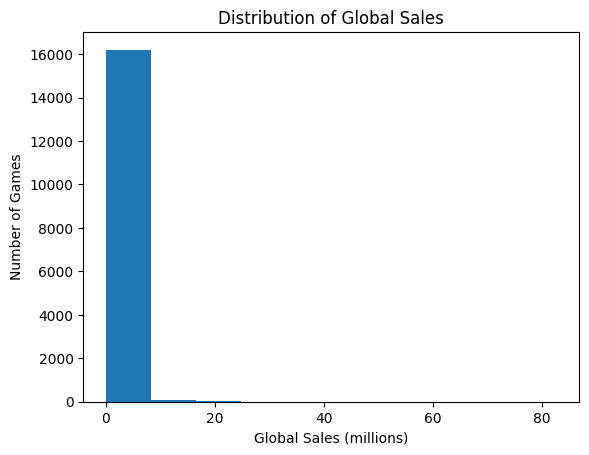

In [55]:
plt.hist(vg_data_merged["global_sales_vgsales"])
plt.title("Distribution of Global Sales")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Number of Games")
plt.show()

### Distribution of Global Sales

The distribution of global sales is expected to be strongly right-skewed.
Most games have relatively low sales, while a small number of titles achieve exceptionally high commercial success.
This pattern is common in entertainment markets, where only a few blockbuster titles dominate total revenue.

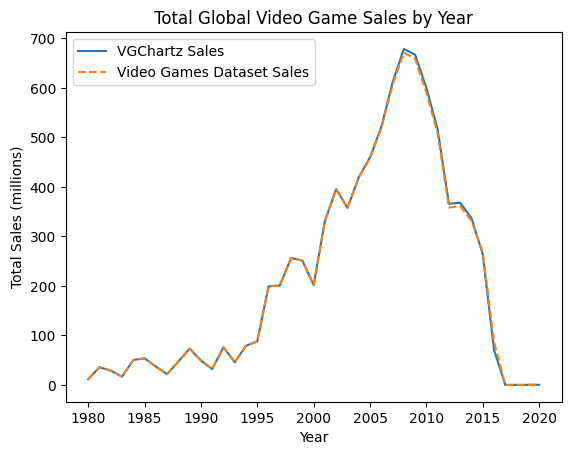

In [52]:
sales_by_year_vgsales = (
    vg_data_merged
    .groupby("year_of_release")["global_sales_vgsales"]
    .sum()
)
sales_by_year_video_games = (
    vg_data_merged
    .groupby("year_of_release")["global_sales_video_games"]
    .sum()
)

plt.plot(
    sales_by_year_vgsales.index,
    sales_by_year_vgsales.values,
    label="VGChartz Sales"
)

plt.plot(
    sales_by_year_video_games.index,
    sales_by_year_video_games.values,
    linestyle="--",
    label="Video Games Dataset Sales"
)

plt.title("Total Global Video Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales (millions)")
plt.legend()
plt.show()

To validate consistency, sales trends from both datasets were plotted. The results closely align, confirming that either source can be used for further analysis.

For consistency, the `global_sales_vgsales` column will be used in subsequent analysis.

The total global sales show a strong peak between approximately 2005 and 2014, followed by a noticeable decline after 2015.
This decline is likely influenced by dataset limitations, such as reduced coverage of newer games and the increasing importance of digital distribution, which may not be fully captured in the data.

Therefore, trends in recent years should be interpreted with caution.

### Sales by Genre

In this section, we analyze how video game sales vary across different genres. This helps identify which types of games tend to perform better commercially.

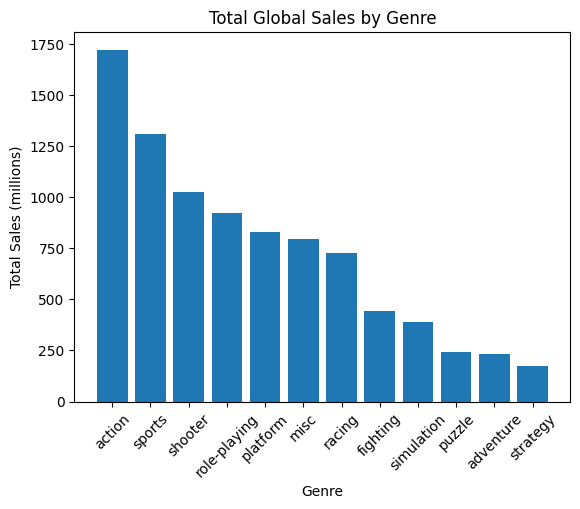

In [58]:
sales_by_genre = (
    vg_data_merged
    .groupby("genre_vgsales")["global_sales_vgsales"]
    .sum()
    .sort_values(ascending=False)
)

plt.bar(sales_by_genre.index, sales_by_genre.values)
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Sales (millions)")
plt.xticks(rotation=45)
plt.show()

The distribution of total sales by genre shows that certain genres dominate the market.

Genres such as Action and Sports tend to achieve significantly higher total sales, while others like Puzzle or Strategy contribute less to overall revenue.

This suggests that genre could play an important role in commercial success.

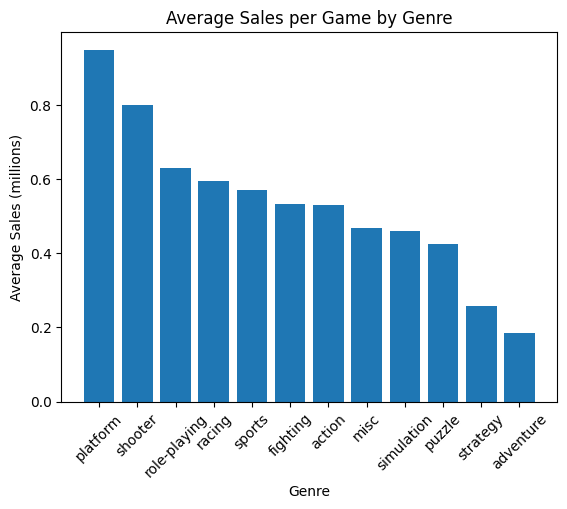

In [59]:
avg_sales_by_genre = (
    vg_data_merged
    .groupby("genre_vgsales")["global_sales_vgsales"]
    .mean()
    .sort_values(ascending=False)
)

plt.bar(avg_sales_by_genre.index, avg_sales_by_genre.values)
plt.title("Average Sales per Game by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Sales (millions)")
plt.xticks(rotation=45)
plt.show()

When analyzing average sales per game, the ranking of genres changes.

This indicates that some genres achieve high total sales due to a large number of releases (e.g platformers), while others perform better on a per-game basis.

Therefore, both total and average sales provide important but different perspectives on genre performance.

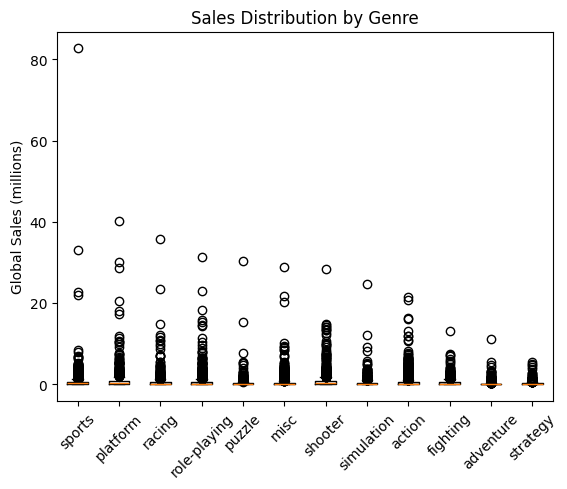

In [60]:
genres = vg_data_merged["genre_vgsales"].unique()

data = [vg_data_merged[vg_data_merged["genre_vgsales"] == g]["global_sales_vgsales"] for g in genres]

plt.boxplot(data, tick_labels=genres)
plt.xticks(rotation=45)
plt.title("Sales Distribution by Genre")
plt.ylabel("Global Sales (millions)")
plt.show()